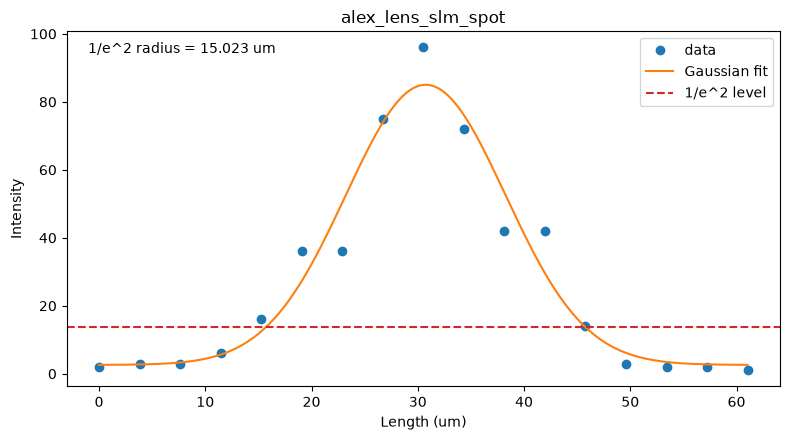

1/e^2 radius = 15.023 um


In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.optimize import curve_fit
except ImportError:
    curve_fit = None

file_path = "beam_profiles/alex_lens_slm_spot.csv"

data = np.genfromtxt(file_path, delimiter=",", skip_header=1, usecols=(0, 1))
x = data[:, 0].astype(float)
y = data[:, 1].astype(float)


def gaussian(x, amplitude, center, sigma, offset):
    return offset + amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)


offset0 = np.percentile(y, 10)
amplitude0 = y.max() - offset0
center0 = x[np.argmax(y)]
weights = np.clip(y - offset0, 0, None)
if np.sum(weights) > 0:
    sigma0 = np.sqrt(np.sum(weights * (x - center0) ** 2) / np.sum(weights))
else:
    sigma0 = np.std(x) / 4
sigma0 = max(sigma0, 1e-6)

if curve_fit is not None:
    try:
        params, _ = curve_fit(
            gaussian,
            x,
            y,
            p0=[amplitude0, center0, sigma0, offset0],
            bounds=([0, x.min(), 1e-9, -np.inf], [np.inf, x.max(), np.inf, np.inf]),
            maxfev=20000,
        )
    except Exception:
        params = np.array([amplitude0, center0, sigma0, offset0], dtype=float)
else:
    params = np.array([amplitude0, center0, sigma0, offset0], dtype=float)

amplitude, center, sigma, offset = params
radius_1e2 = 2 * sigma

x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = gaussian(x_fit, *params)
y_1e2 = offset + amplitude * np.exp(-2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, y, "o", label="data")
ax.plot(x_fit, y_fit, "-", label="Gaussian fit")
ax.axhline(y_1e2, color="C3", linestyle="--", linewidth=1.5, label="1/e^2 level")
ax.set_xlabel("Length (um)")
ax.set_ylabel("Intensity")
ax.set_title(file_path.split("/")[-1].replace(".csv", ""))
ax.legend()
ax.text(
    0.03,
    0.97,
    f"1/e^2 radius = {radius_1e2:.3f} um",
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
)
fig.tight_layout()
plt.show()

print(f"1/e^2 radius = {radius_1e2:.3f} um")